Dataset Shape: (11500, 180)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 176, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 88, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 86, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 43, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,593 (307.00 KB)

 Trainable params: 78,593 (307.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
230/230 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.9401 - loss: 0.1933 - val_accuracy: 0.9478 - val_loss: 0.1197
Epoch 2/40
230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.9613 - loss: 0.1037 - val_accuracy: 0.9582 - val_loss: 0.1069
Epoch 3/40
230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.9622 - loss: 0.0924 - val_accuracy: 0.9614 - val_loss: 0.0980
Epoch 4/40
230/230 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 0.9692 - loss: 0.0836 - val_accuracy: 0.9663 - val_loss: 0.0931
Epoch 5/40
230/230 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.9693 - loss: 0.0795 - val_accuracy: 0.9598 - val_loss: 0.0912
Epoch 6/40
230/230 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.9749 - loss: 0.0680 - val_accuracy: 0.9668 - val_loss: 0.0761
Epoch 7/40
230/230 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 0.9768 - loss: 0.0614 - val_accuracy: 0.9707 - val_loss: 0.0781
Epoch 8/40
230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.9793 - loss: 0.0586 - 

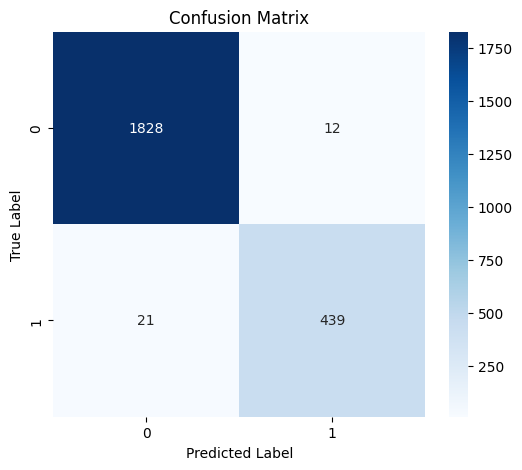

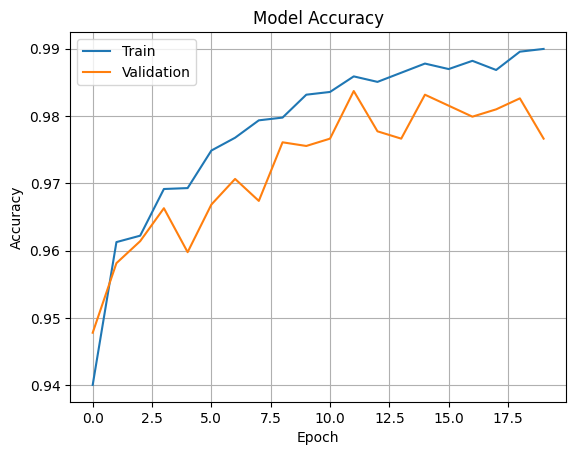

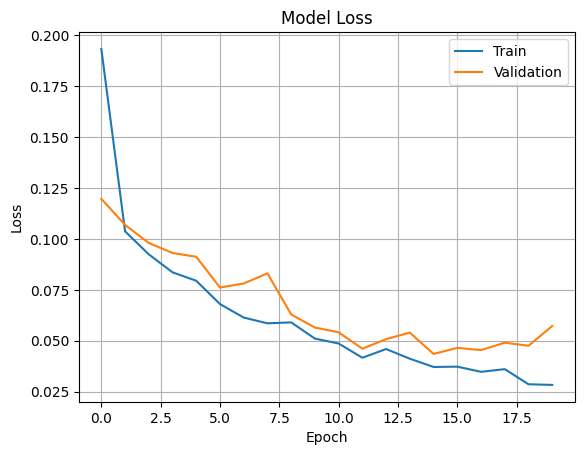

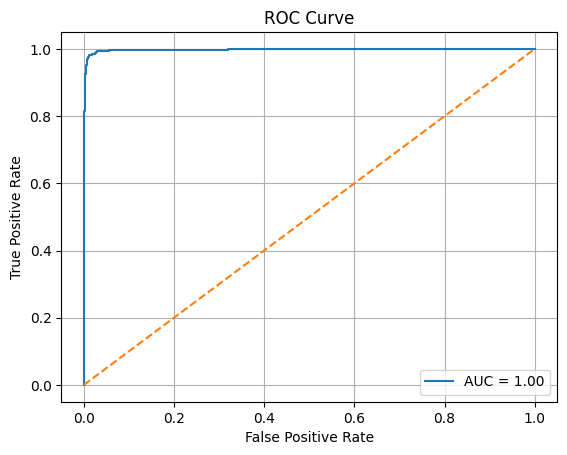

In [3]:
#1.Import Libraries
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# 2.Load Dataset
df=pd.read_csv("Epileptic Seizure Recognition.csv")
print("Dataset Shape:", df.shape)
#Drop unnecessary column
df=df.drop(columns=[df.columns[0]])

# 3.Features & Labels
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Convert to binary classification
y=np.where(y == 1, 1, 0)

#4.Preprocessing
scaler = StandardScaler()
X=scaler.fit_transform(X)

#Reshape for CNN-LSTM
X=X.reshape(X.shape[0], X.shape[1], 1)

#5.Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#6.Model Architecture
model = Sequential([
    Input(shape=(X.shape[1], 1)),
    Conv1D(64, 3, activation='relu'),
    MaxPooling1D(2),
    Conv1D(128, 3, activation='relu'),
    MaxPooling1D(2),
    LSTM(64),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

#7.Training
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

#8.Evaluation
loss, acc = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", acc)

y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Non-Seizure", "Seizure"]))

#9.Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig("confusion_matrix.png")
plt.show()

#10.Accuracy Graph
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.grid()
plt.savefig("accuracy.png")
plt.show()

#11.Loss Graph
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.grid()
plt.savefig("loss.png")
plt.show()

# 12. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.savefig("roc_curve.png")
plt.show()

# 13. Save Model
model.save("eeg_model.keras")